# Sales Performance Analysis

Importing the important Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

Loading Dataset

In [2]:
df = pd.read_csv("Sales_Performance.csv", encoding='latin1')



Checking Dataset

In [3]:
print(df.head())
print(df.shape)
print(df.info())

   ï»¿Row_ID        Order_ID  Order_Date   Ship_Date       Ship_Mode  \
0          1  CA-2017-152156  08-11-2017  11-11-2017    Second Class   
1          2  CA-2017-152156  08-11-2017  11-11-2017    Second Class   
2          3  CA-2017-138688  12-06-2017  16-06-2017    Second Class   
3          4  US-2016-108966  11-10-2016  18-10-2016  Standard Class   
4          5  US-2016-108966  11-10-2016  18-10-2016  Standard Class   

  Customer_ID    Customer_Name    Segment        Country             City  \
0    CG-12520      Claire Gute   Consumer  United States        Henderson   
1    CG-12520      Claire Gute   Consumer  United States        Henderson   
2    DV-13045  Darrin Van Huff  Corporate  United States      Los Angeles   
3    SO-20335    Sean O Donnel   Consumer  United States  Fort Lauderdale   
4    SO-20335    Sean O Donnel   Consumer  United States  Fort Lauderdale   

        State  Postal_Code Region       Product_ID         Category  \
0    Kentucky      42420.0  South

Checking Column names

In [4]:
print(df.columns)

Index(['ï»¿Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub_Category',
       'Product_Name', 'Sales'],
      dtype='object')


Data Cleaning

In [5]:
# Convert dates
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True)
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], dayfirst=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Missing values
print(df.isnull().sum())

ï»¿Row_ID         0
Order_ID          0
Order_Date        0
Ship_Date         0
Ship_Mode         0
Customer_ID       0
Customer_Name     0
Segment           0
Country           0
City              0
State             0
Postal_Code      11
Region            0
Product_ID        0
Category          0
Sub_Category      0
Product_Name      0
Sales             0
dtype: int64


FEATURE ENGINEERING

In [6]:
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Month_Name'] = df['Order_Date'].dt.strftime('%B')
df['Quarter'] = df['Order_Date'].dt.quarter
df['Day_Name'] = df['Order_Date'].dt.day_name()

# Shipping days
df['Shipping_Days'] = (df['Ship_Date'] - df['Order_Date']).dt.days

SAVE CLEANED DATASET

In [7]:
df.to_csv("Superstore_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


KPI Calculation

In [8]:
total_sales = df['Sales'].sum()
total_orders = df['Order_ID'].nunique()
total_customers = df['Customer_ID'].nunique()

avg_order_value = total_sales / total_orders
avg_customer_value = total_sales / total_customers

print("Total Revenue:", round(total_sales,2))
print("Total Orders:", total_orders)
print("Unique Customers:", total_customers)
print("Average Order Value:", round(avg_order_value,2))
print("Average Customer Value:", round(avg_customer_value,2))

Total Revenue: 2261536.78
Total Orders: 4922
Unique Customers: 793
Average Order Value: 459.48
Average Customer Value: 2851.87


Sales Distribution

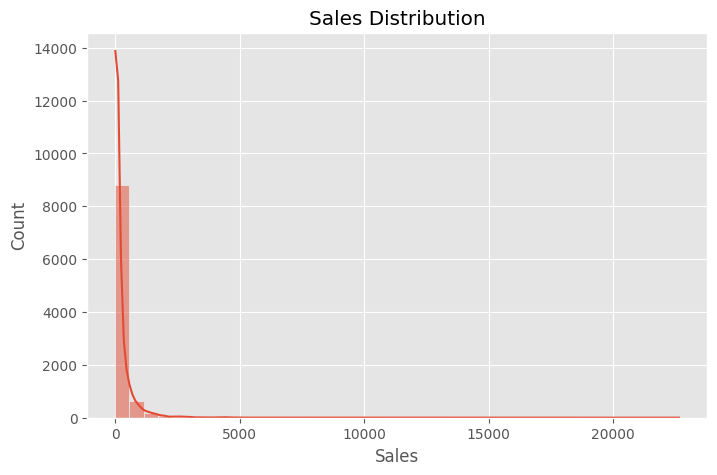

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['Sales'], bins=40, kde=True)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.show()

Regional Performance

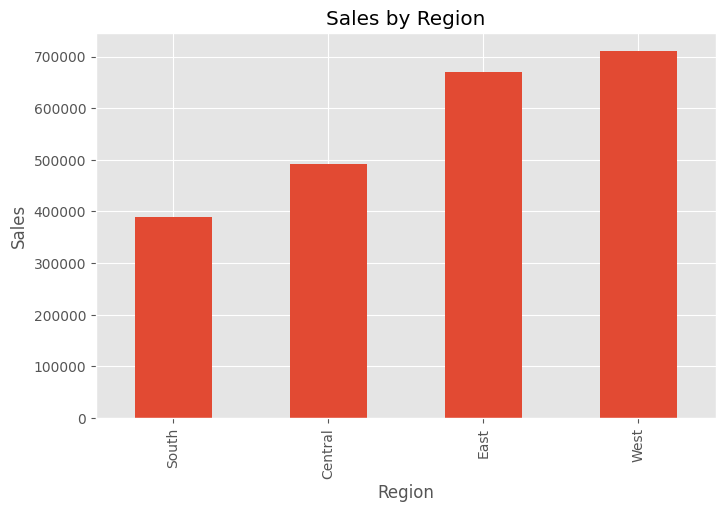

In [10]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values()

plt.figure(figsize=(8,5))
region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.show()

Region Share

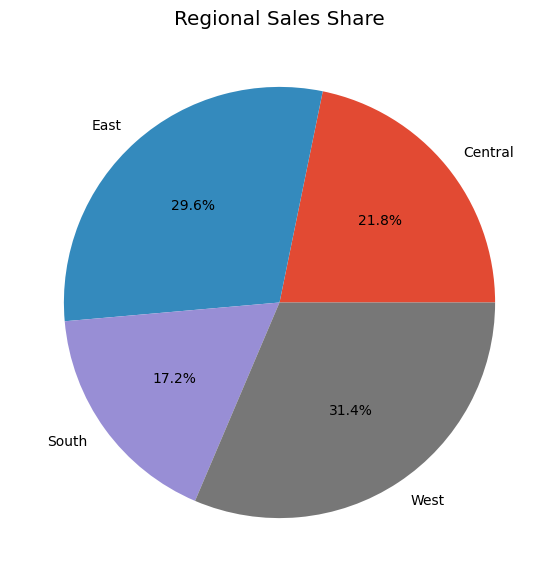

In [11]:
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(7,7))
plt.pie(region_sales,
        labels=region_sales.index,
        autopct='%1.1f%%')
plt.title("Regional Sales Share")
plt.show()

Top States

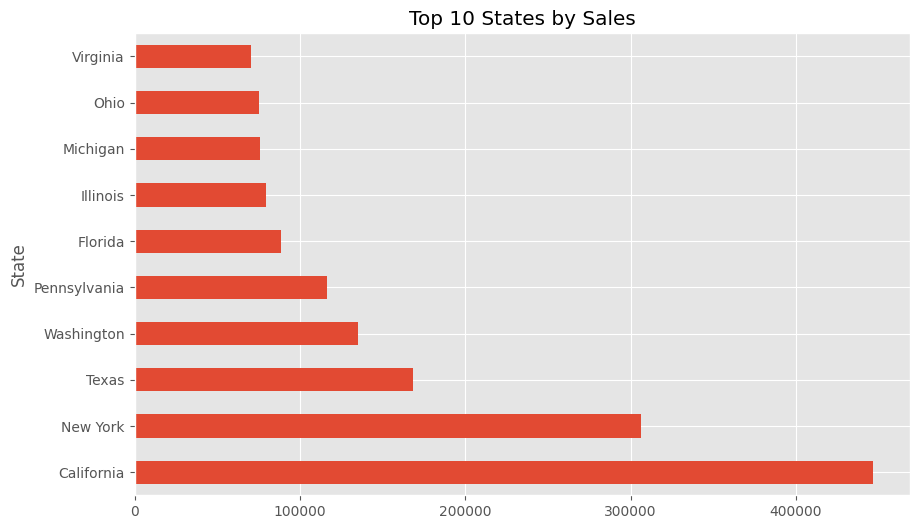

In [12]:
top_states = (
    df.groupby('State')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_states.plot(kind='barh')
plt.title("Top 10 States by Sales")
plt.show()

Category Performance

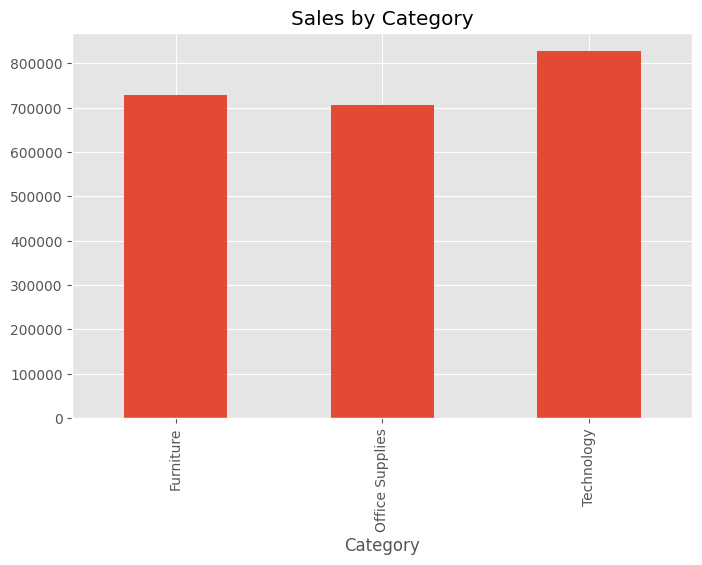

In [13]:
category_sales = df.groupby('Category')['Sales'].sum()

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar')
plt.title("Sales by Category")
plt.show()

Category Share

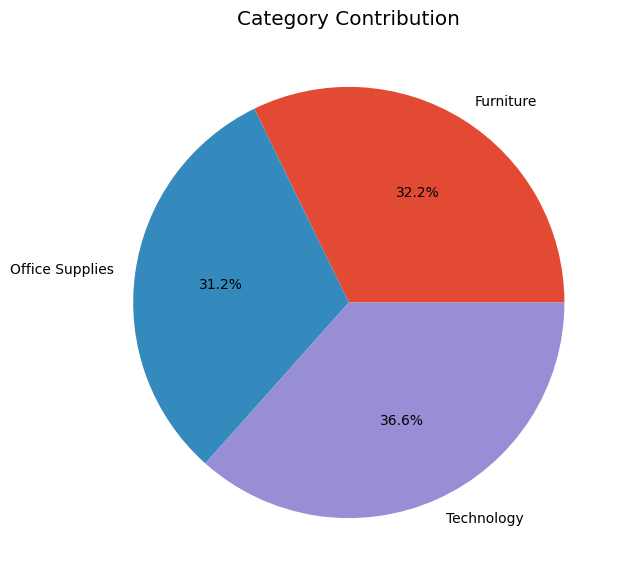

In [14]:
plt.figure(figsize=(7,7))
plt.pie(category_sales,
        labels=category_sales.index,
        autopct='%1.1f%%')
plt.title("Category Contribution")
plt.show()

Sub-Category Analysis

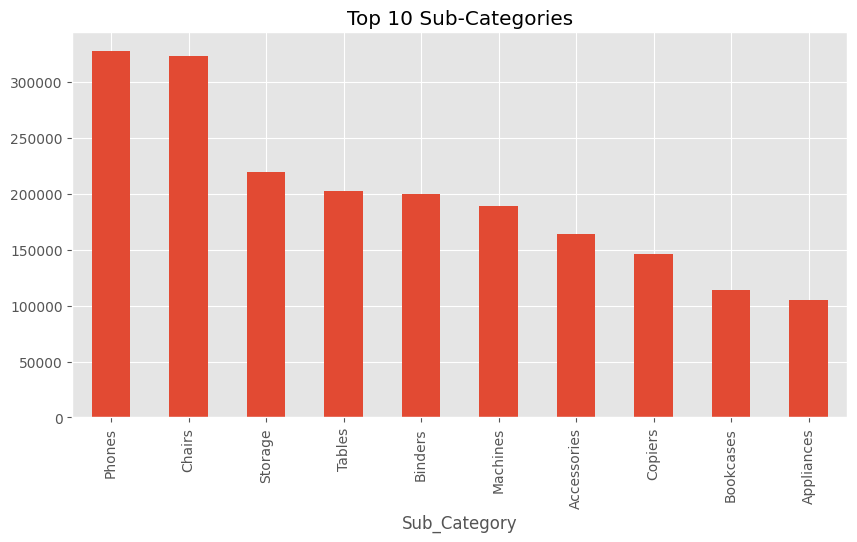

In [15]:
top_sub = (
    df.groupby('Sub_Category')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))
top_sub.plot(kind='bar')
plt.title("Top 10 Sub-Categories")
plt.show()

Best Performing Products

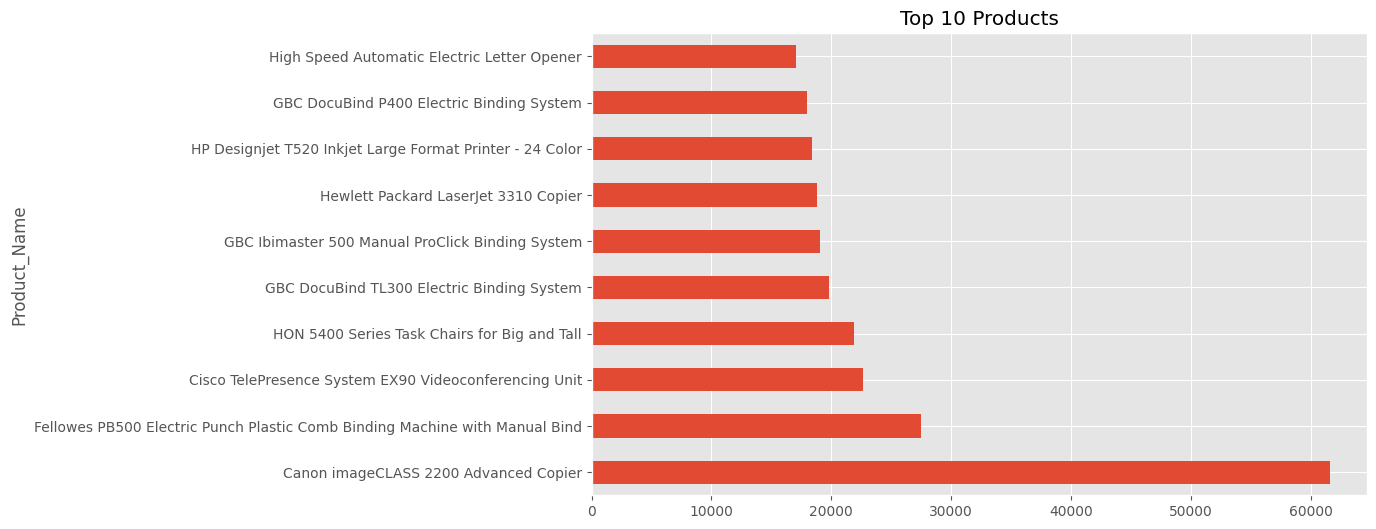

In [16]:
top_products = (
    df.groupby('Product_Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_products.plot(kind='barh')
plt.title("Top 10 Products")
plt.show()

Worst Performing Products

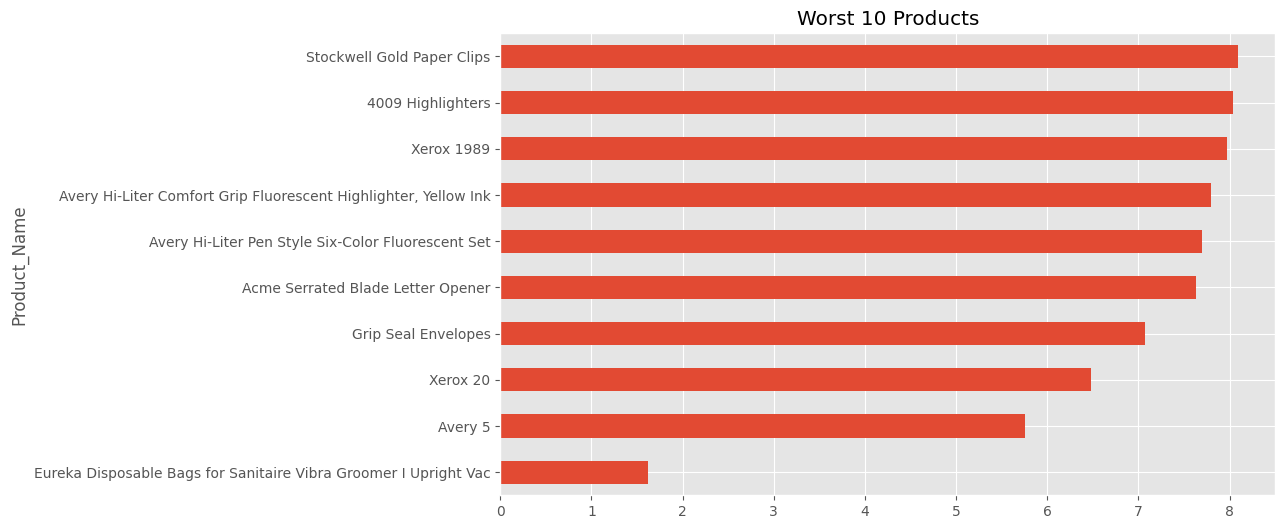

In [17]:
worst_products = (
    df.groupby('Product_Name')['Sales']
    .sum()
    .sort_values()
    .head(10)
)

plt.figure(figsize=(10,6))
worst_products.plot(kind='barh')
plt.title("Worst 10 Products")
plt.show()

Monthly Sales Trend

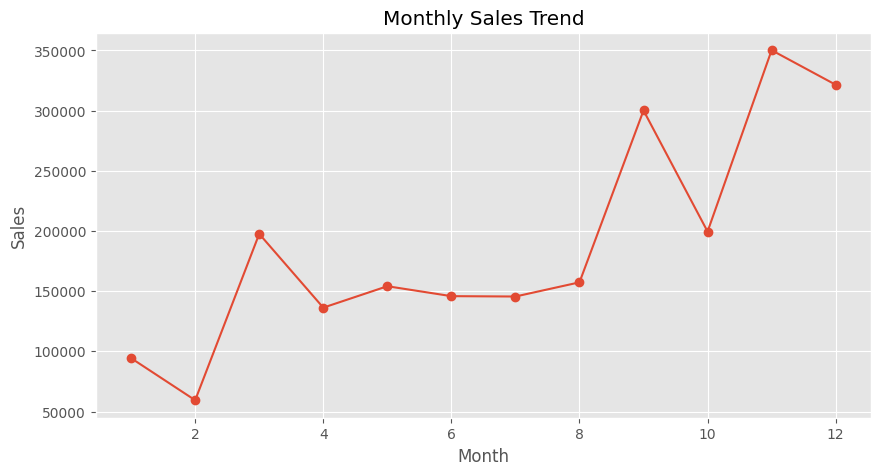

In [18]:
monthly_sales = (
    df.groupby('Month')['Sales']
    .sum()
)

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

Quarterly Sales Trend

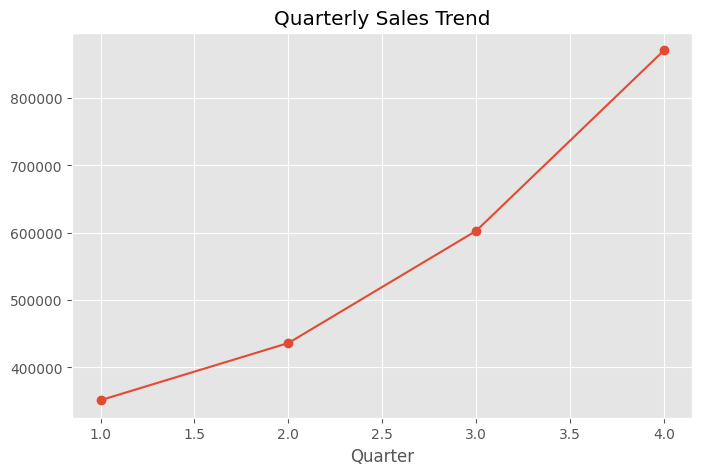

In [19]:
quarter_sales = (
    df.groupby('Quarter')['Sales']
    .sum()
)

plt.figure(figsize=(8,5))
quarter_sales.plot(marker='o')
plt.title("Quarterly Sales Trend")
plt.show()

Yearly Sales Trend

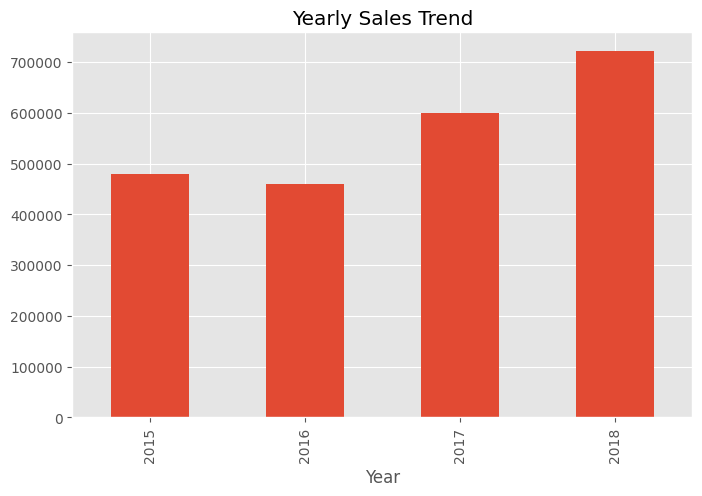

In [20]:
yearly_sales = (
    df.groupby('Year')['Sales']
    .sum()
)

plt.figure(figsize=(8,5))
yearly_sales.plot(kind='bar')
plt.title("Yearly Sales Trend")
plt.show()

Customer Segment Analysis

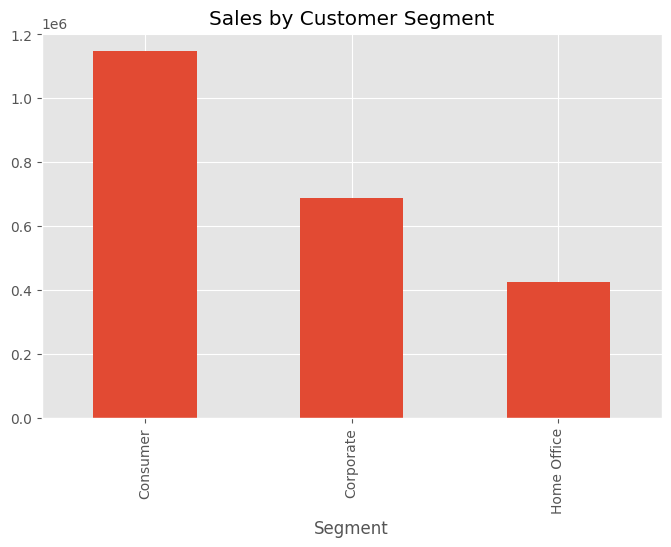

In [21]:
segment_sales = (
    df.groupby('Segment')['Sales']
    .sum()
)

plt.figure(figsize=(8,5))
segment_sales.plot(kind='bar')
plt.title("Sales by Customer Segment")
plt.show()

Ship Mode Analysis

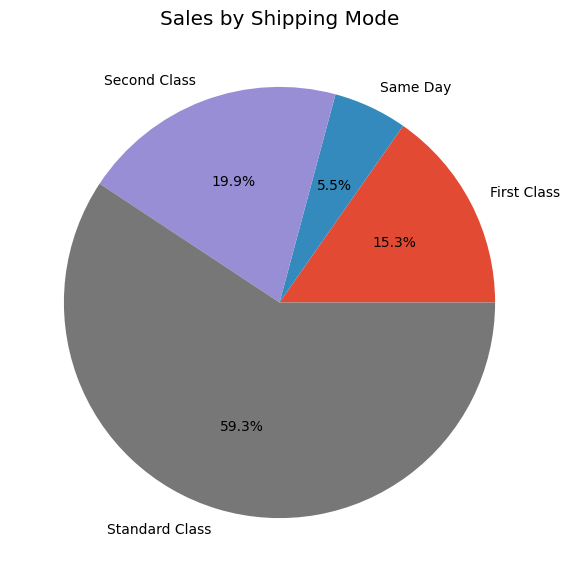

In [22]:
ship_sales = (
    df.groupby('Ship_Mode')['Sales']
    .sum()
)

plt.figure(figsize=(7,7))
plt.pie(ship_sales,
        labels=ship_sales.index,
        autopct='%1.1f%%')
plt.title("Sales by Shipping Mode")
plt.show()

Shipping Days Analysis

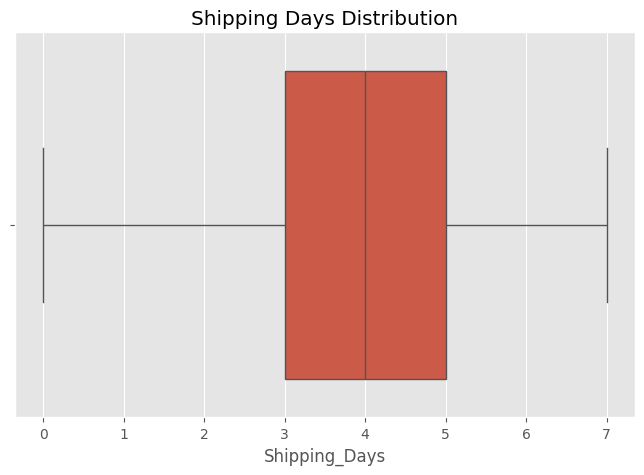

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Shipping_Days'])
plt.title("Shipping Days Distribution")
plt.show()

Top Customers Analysis

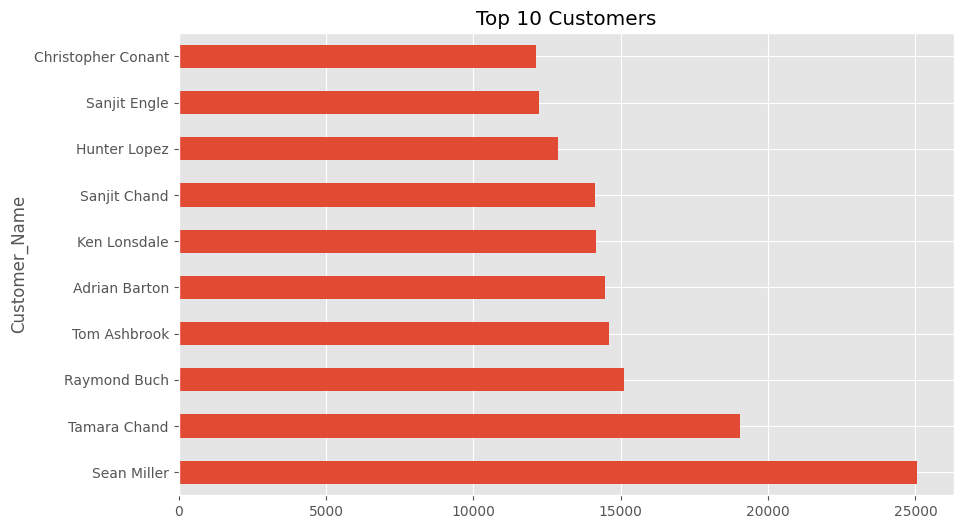

In [24]:
top_customers = (
    df.groupby('Customer_Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_customers.plot(kind='barh')
plt.title("Top 10 Customers")
plt.show()

Heatmap

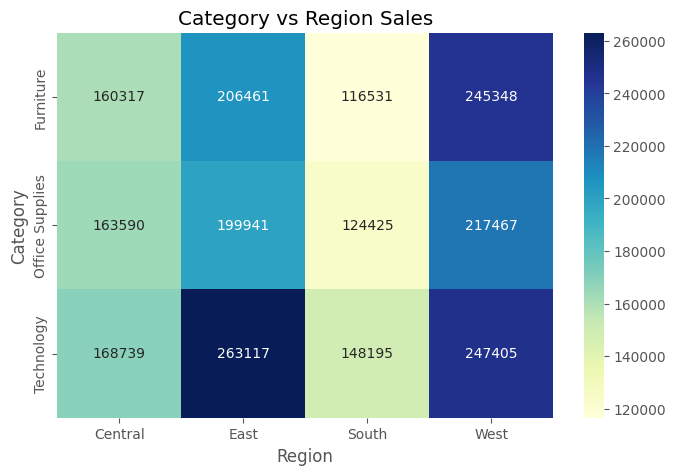

In [25]:
pivot = pd.pivot_table(
    df,
    values='Sales',
    index='Category',
    columns='Region',
    aggfunc='sum'
)

plt.figure(figsize=(8,5))
sns.heatmap(pivot,
            annot=True,
            fmt='.0f',
            cmap='YlGnBu')

plt.title("Category vs Region Sales")
plt.show()

 Insights

In [26]:
print("BEST REGION:",
      df.groupby('Region')['Sales'].sum().idxmax())

print("BEST CATEGORY:",
      df.groupby('Category')['Sales'].sum().idxmax())

print("BEST PRODUCT:",
      df.groupby('Product_Name')['Sales'].sum().idxmax())

print("BEST CUSTOMER SEGMENT:",
      df.groupby('Segment')['Sales'].sum().idxmax())

print("PEAK SALES MONTH:",
      df.groupby('Month_Name')['Sales'].sum().idxmax())

BEST REGION: West
BEST CATEGORY: Technology
BEST PRODUCT: Canon imageCLASS 2200 Advanced Copier
BEST CUSTOMER SEGMENT: Consumer
PEAK SALES MONTH: November


Tactical Improvements for Alfido Tech

In [27]:
print("="*70)
print("TACTICAL IMPROVEMENTS FOR ALFIDO TECH")
print("="*70)

print("\n1. Focus on High-Selling Products")
print("   • Increase inventory levels for top-performing products.")
print("   • Promote these products through targeted marketing campaigns.")
print("   • Bundle them with related products to increase sales.")

print("\n2. Improve Performance of Low-Selling Products")
print("   • Review pricing strategies for underperforming products.")
print("   • Offer discounts and promotional deals.")
print("   • Remove products that consistently generate very low sales.")

print("\n3. Strengthen Regional Sales Strategies")
print("   • Invest more marketing resources in low-performing regions.")
print("   • Analyze successful strategies from top-performing regions.")
print("   • Replicate successful campaigns across other regions.")

print("\n4. Leverage Seasonal Demand")
print("   • Increase inventory before peak sales months.")
print("   • Launch seasonal offers and festive promotions.")
print("   • Use historical sales trends for demand forecasting.")

print("\n5. Enhance Customer Retention")
print("   • Create loyalty and reward programs.")
print("   • Offer personalized recommendations to repeat customers.")
print("   • Focus marketing on the highest-revenue customer segments.")



TACTICAL IMPROVEMENTS FOR ALFIDO TECH

1. Focus on High-Selling Products
   • Increase inventory levels for top-performing products.
   • Promote these products through targeted marketing campaigns.
   • Bundle them with related products to increase sales.

2. Improve Performance of Low-Selling Products
   • Review pricing strategies for underperforming products.
   • Offer discounts and promotional deals.
   • Remove products that consistently generate very low sales.

3. Strengthen Regional Sales Strategies
   • Invest more marketing resources in low-performing regions.
   • Analyze successful strategies from top-performing regions.
   • Replicate successful campaigns across other regions.

4. Leverage Seasonal Demand
   • Increase inventory before peak sales months.
   • Launch seasonal offers and festive promotions.
   • Use historical sales trends for demand forecasting.

5. Enhance Customer Retention
   • Create loyalty and reward programs.
   • Offer personalized recommendations